# Análisis de Ventas en Amazon: Un Enfoque en E-commerce y Retail

## Introducción

El presente análisis tiene como objetivo explorar y comprender el comportamiento de las ventas en Amazon a partir de un conjunto de datos simulado que contiene 250 registros de transacciones. A través de este estudio, se busca identificar patrones relevantes en las ventas, el comportamiento de los clientes, los métodos de pago más utilizados y la distribución de los productos vendidos en diferentes categorías.

Para lograrlo, se emplearon herramientas de análisis de datos como Pandas, NumPy, Matplotlib y Seaborn, y se realizó una cuidadosa preparación de los datos para garantizar su calidad y consistencia.

El análisis se estructuró en tres ejes principales:

1. Análisis general de ventas:

- ¿Cuál es la distribución del total de ventas?
- ¿Cuál es el ticket promedio por pedido?
- ¿Cómo se distribuyen los pedidos según su estado (Completado, Pendiente, Cancelado)?
- ¿Cuál es la evolución de las ventas a lo largo del tiempo?
- ¿Cuál es el día de la semana con mayor volumen de ventas?

2. Análisis de productos:

- ¿Cuáles son los productos más vendidos por cantidad?
- ¿Cuáles son los productos que más ingresos generaron?
- ¿Qué categoría genera más ventas totales?

3. Análisis de métodos de pago:

- ¿Qué método de pago es el más utilizado?
- ¿Existe alguna relación entre el método de pago y el estado del pedido?
- ¿Cuál es el total de ventas por método de pago?

Este enfoque integral permitirá extraer insights valiosos para la toma de decisiones estratégicas, orientadas a optimizar los procesos comerciales y mejorar la experiencia del cliente.

## Entendimiento de los datos

📂 Fuente: Kaggle.com

📊 Descripción:
Este dataset simulado contiene 250 registros de ventas realizadas en Amazon, incluyendo variables relacionadas con los productos, clientes, métodos de pago y estado de los pedidos. Está diseñado para análisis de ventas, comportamiento del cliente y visualización de ingresos.

📌 Variables principales:

- Fecha del pedido
- Producto y categoría
- Precio, cantidad y ventas totales
- Nombre y ubicación del cliente
- Método de pago
- Estado del pedido (Completado, Pendiente, Cancelado)

-----

## 1. Inicialización

In [1]:
# Importar librerias
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importar el dataset 
data = pd.read_csv('data/raw/amazon_sales_data 2025.csv')

## 2. Preparación de los datos

In [3]:
# Visualizar informacion de la data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Order ID           250 non-null    object
 1   Date               250 non-null    object
 2   Product            250 non-null    object
 3   Category           250 non-null    object
 4   Price              250 non-null    int64 
 5   Quantity           250 non-null    int64 
 6   Total Sales        250 non-null    int64 
 7   Customer Name      250 non-null    object
 8   Customer Location  250 non-null    object
 9   Payment Method     250 non-null    object
 10  Status             250 non-null    object
dtypes: int64(3), object(8)
memory usage: 21.6+ KB


In [4]:
# Visualizar la data
data

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
0,ORD0001,14-03-25,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled
1,ORD0002,20-03-25,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending
2,ORD0003,15-02-25,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled
3,ORD0004,19-02-25,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending
4,ORD0005,10-03-25,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending
...,...,...,...,...,...,...,...,...,...,...,...
245,ORD0246,17-03-25,T-Shirt,Clothing,20,2,40,Daniel Harris,Miami,Debit Card,Cancelled
246,ORD0247,30-03-25,Jeans,Clothing,40,1,40,Sophia Miller,Dallas,Debit Card,Cancelled
247,ORD0248,05-03-25,T-Shirt,Clothing,20,2,40,Chris White,Denver,Debit Card,Cancelled
248,ORD0249,08-03-25,Smartwatch,Electronics,150,3,450,Emily Johnson,New York,Debit Card,Cancelled


### 2.1. Modificar tipo de datos en columna de fechas

Modificar el tipo de dato en la columna 'Date' a  formato fecha.

In [5]:
# Cambiar la columna Date a formato fecha
data['Date'] = pd.to_datetime(data['Date'])


/var/folders/82/grjgs_q959j1pwfb817_nsl80000gn/T/ipykernel_7244/2028101290.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'])


In [6]:
# Evaluar rango de fechas
print('Primera fecha:', data['Date'].min())
print('Ultima fecha:', data['Date'].max())

Primera fecha: 2025-01-03 00:00:00
Ultima fecha: 2025-12-03 00:00:00


El dataset contiene registros de pedidos entre el 3 de enero de 2025 y el 3 de diciembre de 2025, es decir, abarca 11 meses exactos. Lo cual no es representativo de datos reales para el año en curso.

In [7]:
# Filtrar el dataset a la fecha de hoy
df = data[data["Date"] <= pd.Timestamp.today()]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191 entries, 0 to 249
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           191 non-null    object        
 1   Date               191 non-null    datetime64[ns]
 2   Product            191 non-null    object        
 3   Category           191 non-null    object        
 4   Price              191 non-null    int64         
 5   Quantity           191 non-null    int64         
 6   Total Sales        191 non-null    int64         
 7   Customer Name      191 non-null    object        
 8   Customer Location  191 non-null    object        
 9   Payment Method     191 non-null    object        
 10  Status             191 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 17.9+ KB


Aunque el dataset contiene solo 191 registros, incluye fechas actualizadas hasta el día de hoy, lo que permite un análisis más consistente.

### 2.2. Datos ausentes y duplicados

In [8]:
# Verificar datos ausentes 
df.isna().sum()

Order ID             0
Date                 0
Product              0
Category             0
Price                0
Quantity             0
Total Sales          0
Customer Name        0
Customer Location    0
Payment Method       0
Status               0
dtype: int64

In [9]:
# Verificar datos duplicados 
df.duplicated().sum()

np.int64(0)

In [10]:
# Contar los IDs unicos
df['Customer Name'].nunique()

10

No hay datos duplicados ni ausentes. 
En cuanto a los Ids, cuento con 10 IDs o clientes únicos, que han realizado varias ordenes  de compra.

### 2.3. Estadísticas descriptivas

In [11]:
# Ver la descripcion de la data
df.describe()

,Date,Price,Quantity,Total Sales
count,191,191.000000,191.000000,191.000000
mean,2025-03-08 10:33:17.905759232,331.518325,2.863874,937.382199
min,2025-01-03 00:00:00,15.000000,1.000000,15.000000
25%,2025-02-21 00:00:00,40.000000,2.000000,110.000000
50%,2025-03-14 00:00:00,150.000000,3.000000,300.000000
75%,2025-03-23 00:00:00,600.000000,4.000000,1200.000000
max,2025-05-03 00:00:00,1200.000000,5.000000,6000.000000
std,NaN,377.257484,1.429871,1244.685314


### 2.4. Outliers 

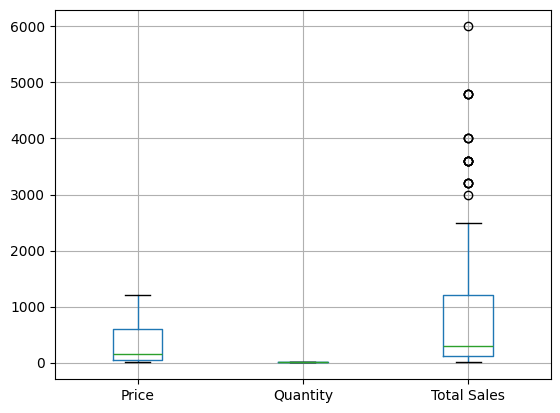

In [12]:
# Verficar outliers 
df.boxplot()
plt.show()

Puedo notar algunos valores que parecen atípicos en la columnas de Ventas totales.

In [13]:
# Verificar las ventas totales sobre los 300O USD
df[df['Total Sales'] > 3000]

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
23,ORD0024,2025-03-24,Refrigerator,Home Appliances,1200,3,3600,Chris White,Dallas,Credit Card,Cancelled
44,ORD0045,2025-03-15,Refrigerator,Home Appliances,1200,3,3600,Daniel Harris,New York,Credit Card,Pending
63,ORD0064,2025-02-13,Refrigerator,Home Appliances,1200,4,4800,Emily Johnson,Denver,PayPal,Pending
68,ORD0069,2025-02-25,Refrigerator,Home Appliances,1200,4,4800,David Lee,Boston,Gift Card,Pending
73,ORD0074,2025-03-25,Refrigerator,Home Appliances,1200,4,4800,Jane Smith,Dallas,Gift Card,Cancelled
90,ORD0091,2025-03-02,Laptop,Electronics,800,4,3200,Daniel Harris,Houston,Gift Card,Pending
110,ORD0111,2025-03-31,Laptop,Electronics,800,4,3200,Emma Clark,Los Angeles,Credit Card,Completed
115,ORD0116,2025-03-19,Laptop,Electronics,800,4,3200,Emma Clark,Los Angeles,Amazon Pay,Completed
119,ORD0120,2025-02-16,Laptop,Electronics,800,5,4000,Emily Johnson,Denver,PayPal,Completed
125,ORD0126,2025-04-02,Refrigerator,Home Appliances,1200,5,6000,Olivia Wilson,Chicago,Gift Card,Pending


Los valores extremos en la columna de Ventas Totales, corresponden a compras de mayor valor en la categoría de refrigeradores y laptop. Aunque son pocas, no se consideran outliers, ya que representan transacciones reales dentro del contexto del negocio. Sin embargo, sí tienen un impacto significativo en la distribución de las ventas, especialmente en el promedio de ventas totales.

In [14]:
# Guardar el df procesado como archivo csv
# df.to_csv('data/processed/data_amazon_processed.csv', index=False)

## 3. Análisis exploratorio

### 3.1. Análisis general de ventas

1. ¿Cúal es la distribución del total de ventas?
2. ¿Cuál es el ticket promedio por pedido?
3. ¿Cómo se distribuyen los pedidos por estado (Completado, Pendiente, Cancelado)?
4. ¿Cuál es la evolución de las ventas a lo largo del tiempo?
5. ¿Cuál es el día de la semana con mayor volumen de ventas?

### 3.1.1. Distribución del total de ventas

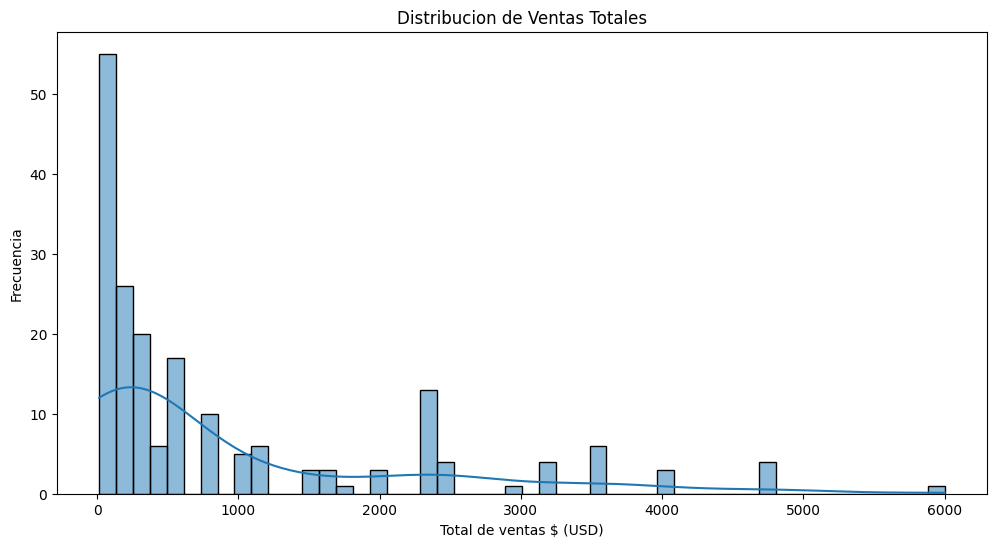

In [15]:
# Graficar la distribucion de precios en los anuncios
plt.figure(figsize=(12, 6))
sns.histplot(df['Total Sales'], bins=50, kde=True)
plt.title('Distribucion de Ventas Totales')
plt.xlabel('Total de ventas $ (USD)')
plt.ylabel('Frecuencia')
plt.show()

#### Distribución de Ventas Totales 

La distribución de las ventas totales muestra que la mayoría de las transacciones se concentran entre 0 y 1000 USD, con un pick alrededor de los 350 USD. Aunque existen algunos valores extremos que superan los $3000 y alcanzan hasta los $6000, representan una minoría dentro del conjunto de datos.

### 3.1.2. Ticket promedio por órden de compra

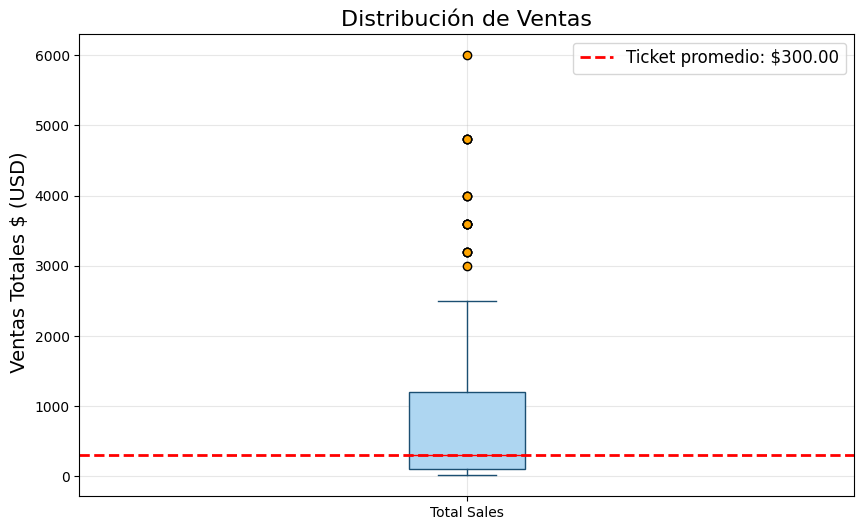

In [16]:
# Calcular ticket promedio mediante la mediana
ticket_promedio = df['Total Sales'].median()

# Crear boxplot con relleno pastel y figura más grande
plt.figure(figsize=(10, 6))
box = df['Total Sales'].plot.box(patch_artist=True, boxprops=dict(facecolor='#AED6F1', color='#1B4F72'),
                                medianprops=dict(color='red'), whiskerprops=dict(color='#1B4F72'),
                                capprops=dict(color='#1B4F72'), flierprops=dict(markerfacecolor='orange', marker='o'))

plt.axhline(ticket_promedio, color='red', linestyle='--', linewidth=2, label=f'Ticket promedio: ${ticket_promedio:.2f}')
plt.title('Distribución de Ventas', fontsize=16)
plt.ylabel(' Ventas Totales $ (USD)', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(alpha=0.3)
plt.show()


#### Ticket promedio por órden de compra

A partir del histograma de distribución, identifiqué la presencia de valores atípicos en las ventas totales: un pequeño grupo de pedidos con montos entre $3000 y $6000. Aunque son pocos, estos valores extremos podrían distorsionar el promedio y no representar fielmente el comportamiento habitual de las ventas, por esta razón, opté por calcular el ticket promedio utilizando la mediana, una métrica más robusta frente a outliers. 

EL resultado es un ticket promedio de $300 USD

### 3.1.3. Distribución porcentual de órdenes de compra por estado del pedido

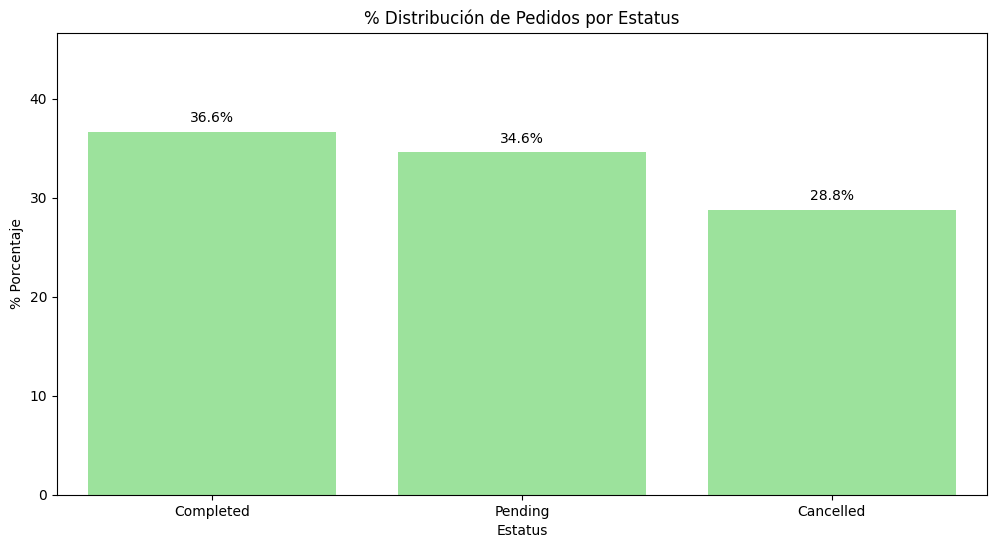

In [17]:
# Calcular porcentaje por estado
status_pct = df['Status'].value_counts(normalize=True).mul(100).reset_index()
status_pct.columns = ['Status', 'Porcentaje']
status_pct = status_pct.sort_values('Porcentaje', ascending=False)

# Crear un grafico 
plt.figure(figsize=(12,6))
ax = sns.barplot(x='Status', y='Porcentaje', data=status_pct, color='lightgreen')

# Agregar etiquetas de porcentaje sobre las barras
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 1, f'{p.get_height():.1f}%', ha='center')

plt.title('% Distribución de Pedidos por Estatus')
plt.ylabel('% Porcentaje')
plt.xlabel('Estatus')
plt.ylim(0, status_pct['Porcentaje'].max() + 10)
plt.show()

#### % Distribución de órdenes de compra por estado del pedido

Del total de pedidos, solo casi un 37% se completa exitosamente, mientras que el resto se divide entre pedidos pendientes (34%) y cancelados (29%). Esta distribución sugiere que una parte significativa del proceso no llega a finalizarse, ya sea porque los pedidos no avanzan o terminan siendo cancelados. Si bien no se cuenta con información sobre las causas específicas, los datos reflejan una oportunidad importante de mejora para aumentar la eficiencia y reducir la pérdida de pedidos.

### 3.1.4. Evolución de la ventas a lo largo del tiempo

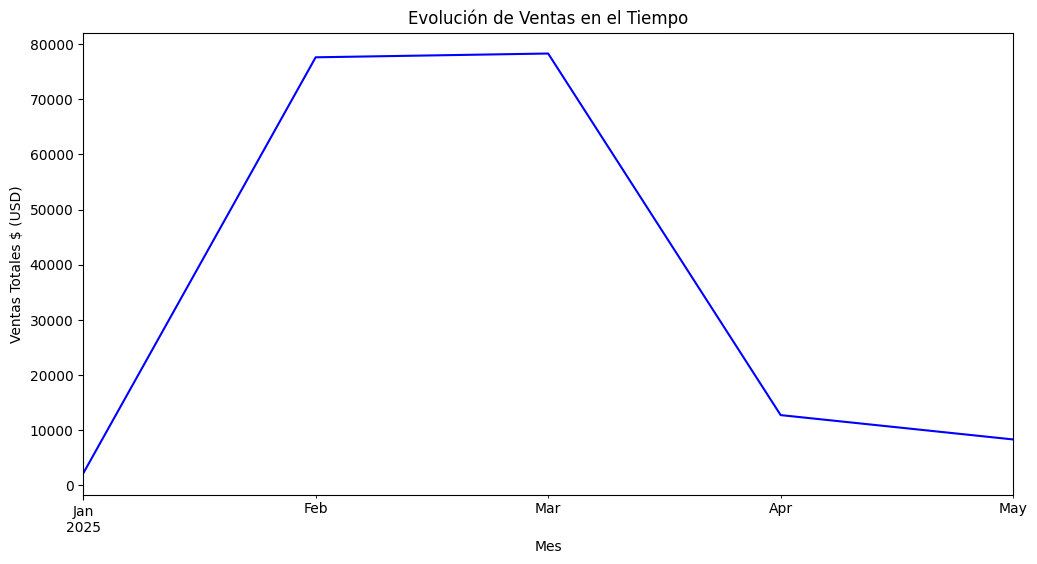

In [18]:
# Graficar las ventas totales acumuladas en el tiempo analizado
sales_over_time = df.groupby(df['Date'].dt.to_period('M'))['Total Sales'].sum()

plt.figure(figsize=(12, 6))
sales_over_time.plot(kind='line',color='blue')
plt.title('Evolución de Ventas en el Tiempo')
plt.xlabel('Mes')
plt.ylabel('Ventas Totales $ (USD)')
plt.show()

#### Evolución de las ventas a lo largo del tiempo
Las mayores ganancias se registraron entre febrero y marzo; en abril comenzaron a descender, y esta tendencia continúa hasta mayo.

### 3.1.5. Volumen de pedidos por día de la semana

/var/folders/82/grjgs_q959j1pwfb817_nsl80000gn/T/ipykernel_7244/1701860860.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Día de la Semana'] = df['Date'].dt.day_name()


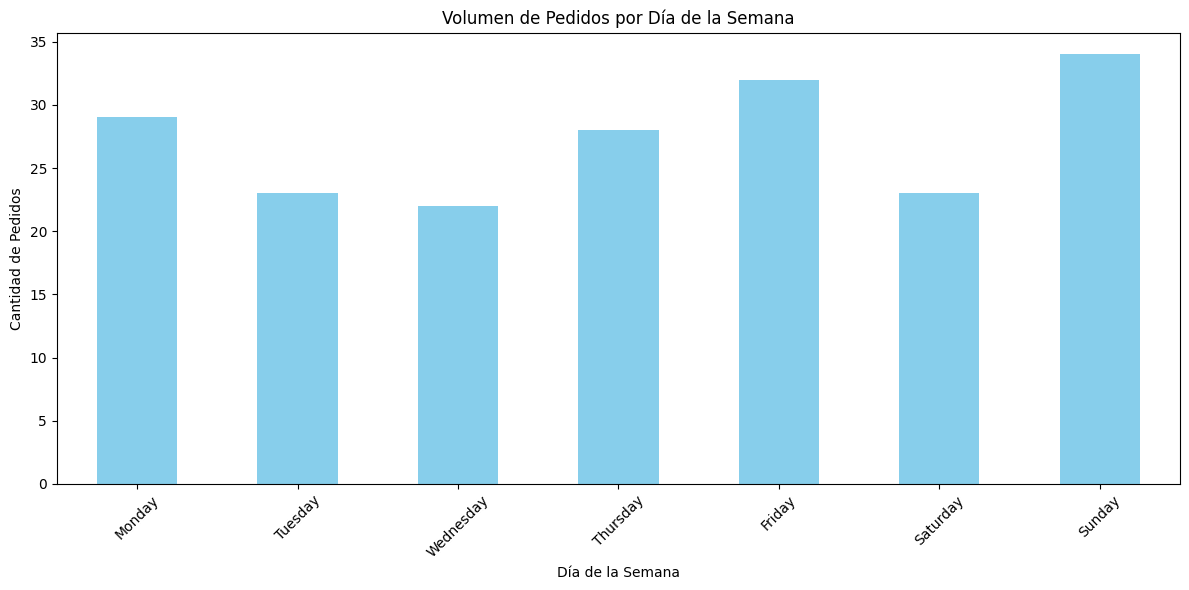

In [19]:
# Extraer el día de la semana y contar pedidos
df['Día de la Semana'] = df['Date'].dt.day_name()
pedidos_por_dia = df.groupby('Día de la Semana')['Order ID'].count().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

# Crear gráfico de barras
plt.figure(figsize=(12, 6))
pedidos_por_dia.plot(kind='bar', color='skyblue')
plt.title('Volumen de Pedidos por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Cantidad de Pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Volumen de pedidos por día de la semana

El domingo es el día en que se realizan más órdenes de compra en comparación con los demás días de la semana.

## 3.2. Análisis de Productos

1. ¿Cuáles son los productos más vendidos por cantidad?
2. ¿Cuáles son los productos que más ingresos generaron?
4. ¿Qué categoría genera más ventas totales?


### 3.2.1. Productos más vendidos por cantidad

/var/folders/82/grjgs_q959j1pwfb817_nsl80000gn/T/ipykernel_7244/267297917.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Product', x='Quantity', data=product_qty, palette=palette, ax=ax)


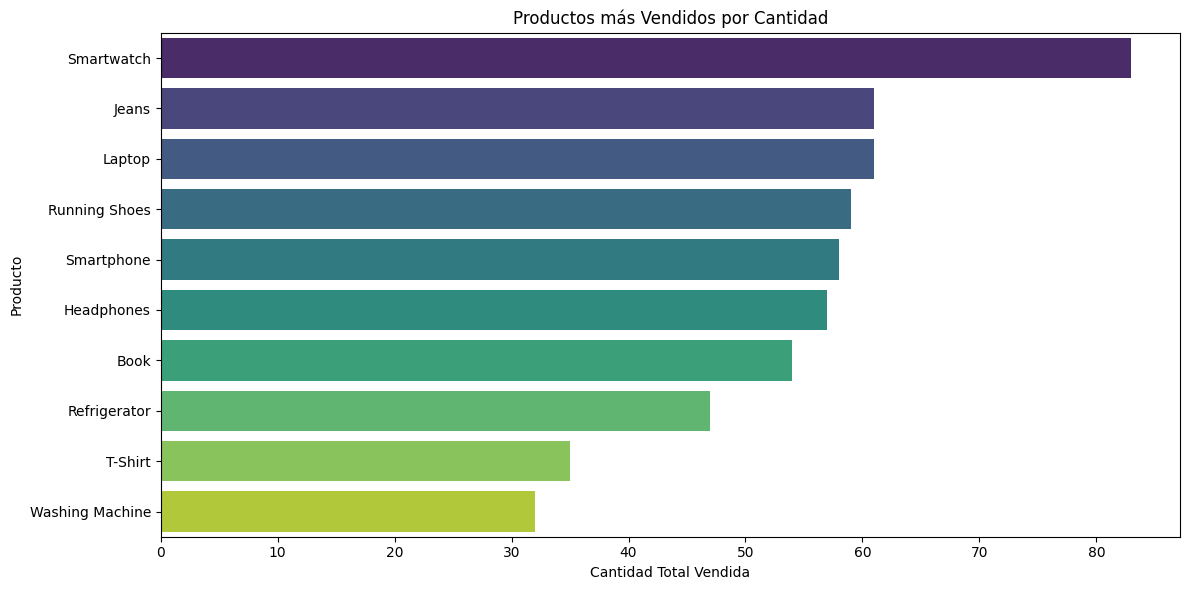

In [20]:
# Sumar cantidades vendidas por producto
product_qty = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).reset_index()

# Crear el gráfico con barras horizontales
palette = sns.color_palette("viridis", n_colors=len(product_qty))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(y='Product', x='Quantity', data=product_qty, palette=palette, ax=ax)
ax.set_title('Productos más Vendidos por Cantidad')
ax.set_xlabel('Cantidad Total Vendida')
ax.set_ylabel('Producto')
plt.tight_layout()
plt.show()


#### Productos más vendidos por cantidad

El reloj inteligente fue el producto con mayor volumen de ventas, seguido por los pantalones jeans y las laptops.

### 3.2.3. Ingresos generados por producto

/var/folders/82/grjgs_q959j1pwfb817_nsl80000gn/T/ipykernel_7244/3104227524.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product', y='Total Sales', data=product_profit, palette=palette, ax=ax)


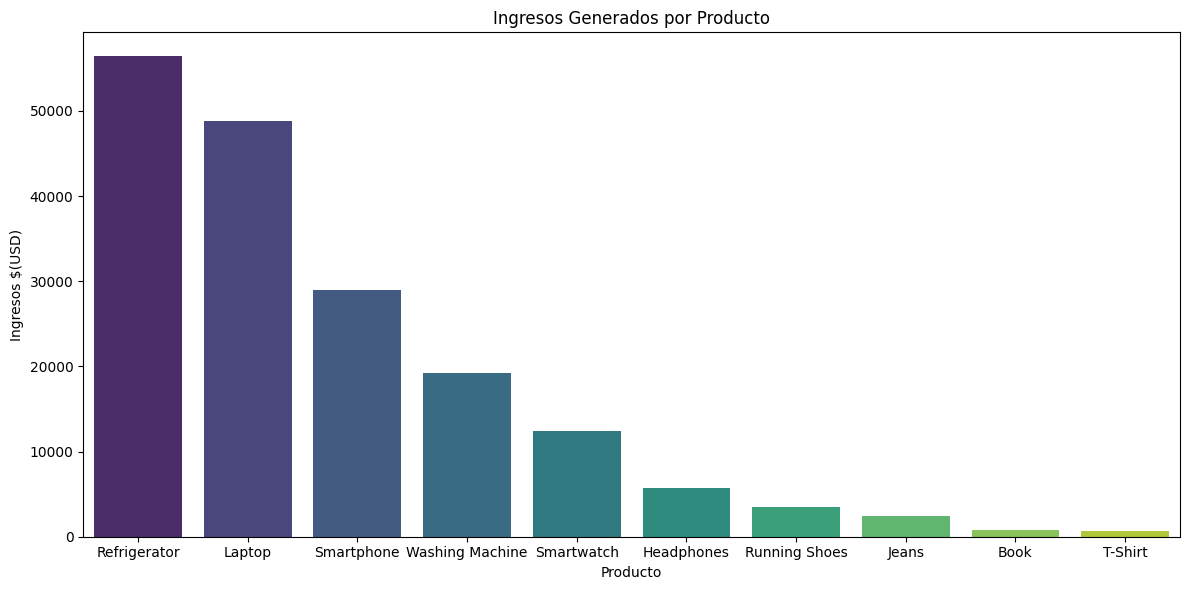

In [21]:
# Sumar ingresos por producto
product_profit = df.groupby('Product')['Total Sales'].sum().sort_values(ascending=False).reset_index()

# Crear el grafico
palette = sns.color_palette("viridis", n_colors=len(product_profit))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='Product', y='Total Sales', data=product_profit, palette=palette, ax=ax)
ax.set_title('Ingresos Generados por Producto')
ax.set_xlabel('Producto')
ax.set_ylabel('Ingresos $(USD)')
plt.tight_layout()
plt.show()


#### Ingresos por producto 

A pesar de que el producto refrigerador ocupa el octavo lugar en cuanto a cantidad de unidades vendidas, es el que generó mayores ingresos. Esto probablemente se debe a su precio más elevado en comparación con los demás productos. En segundo lugar en ingresos se encuentra la laptop, seguida por el smartphone.
Esto sugiere un patrón: los productos con precios más altos generan más ingresos a pesar de venderse en menor cantidad, mientras que los productos de menor precio, aunque tienen mayores volúmenes de venta, no superan los ingresos de aquellos más costosos.

### 3.2.4. Ingresos generados por categoría

/var/folders/82/grjgs_q959j1pwfb817_nsl80000gn/T/ipykernel_7244/860384282.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Total Sales', data=category_profit, palette=palette, ax=ax)


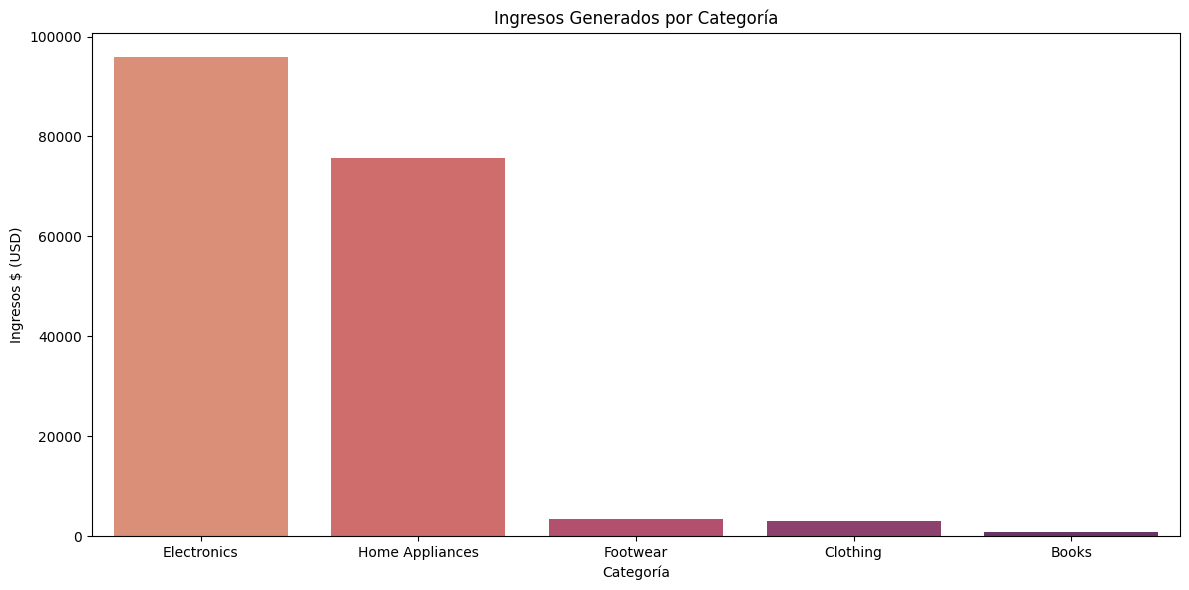

In [22]:
# Sumar ingresos por categoria
category_profit = df.groupby('Category')['Total Sales'].sum().sort_values(ascending=False).reset_index()

# Crear el grafico
palette = sns.color_palette("flare", n_colors=len(category_profit))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='Category', y='Total Sales', data=category_profit, palette=palette, ax=ax)
ax.set_title('Ingresos Generados por Categoría')
ax.set_xlabel('Categoría')
ax.set_ylabel('Ingresos $ (USD)')
plt.tight_layout()
plt.show()

#### ¿Cuál es la categoría que genera más ingresos?

La categoría con mayores ingresos es la de productos electrónicos (como laptops, smartphones y smartwatches), seguida por la de electrodomésticos.

## 3.3. Análisis de Métodos de Pago

1. ¿Qué método de pago es el más utilizado?
2. ¿Hay alguna relación entre método de pago y estado del pedido?
3. ¿Cuál es el total de ventas por método de pago?

### 3.3.1. Métodos de pago más utilizados

/var/folders/82/grjgs_q959j1pwfb817_nsl80000gn/T/ipykernel_7244/79266510.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Payment Method', y='Porcentaje', data=pay_method, palette=palette, ax=ax)


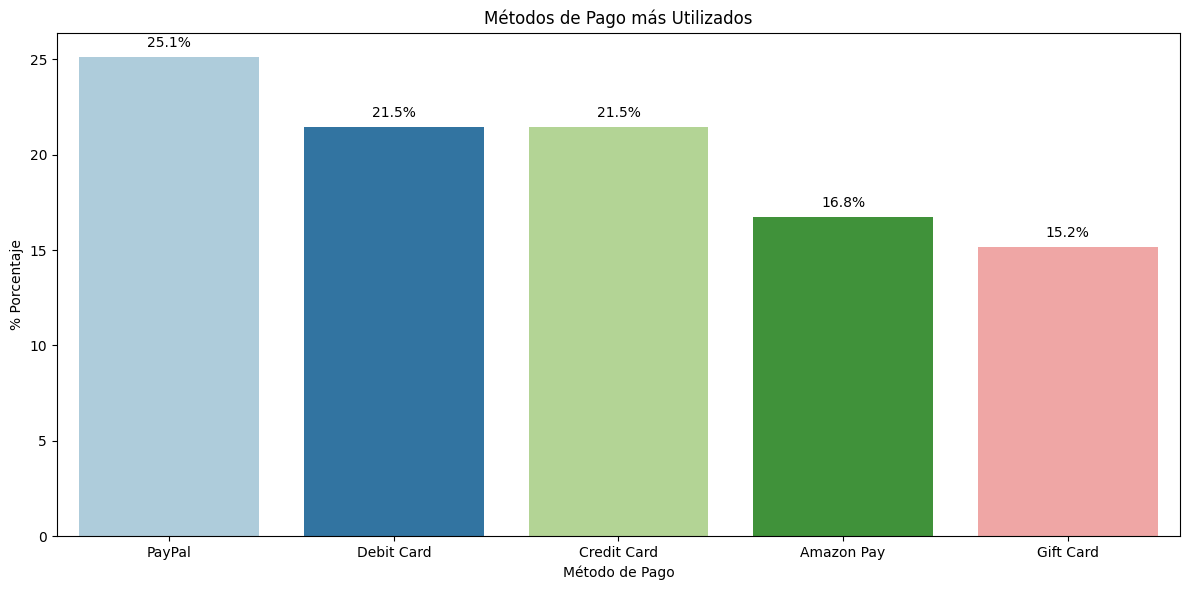

In [23]:
# Calcular el porcentaje por medio de pago
pay_method = df['Payment Method'].value_counts(normalize=True).mul(100).reset_index()
pay_method.columns = ['Payment Method', 'Porcentaje']

# Crear el gráfico
fig, ax = plt.subplots(figsize=(12, 6))

palette = sns.color_palette("Paired", n_colors=len(pay_method))
sns.barplot(x='Payment Method', y='Porcentaje', data=pay_method, palette=palette, ax=ax)

# Agregar etiquetas de porcentaje sobre las barras (después de crear el gráfico)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.5, f'{p.get_height():.1f}%', ha='center')

# Personalización del gráfico
ax.set_title('Métodos de Pago más Utilizados')
ax.set_xlabel('Método de Pago')
ax.set_ylabel('% Porcentaje')
plt.tight_layout()
plt.show()

#### Método de pago más utilizado

PayPal es el método de pago más utilizado, con un 25 % de preferencia, seguido por las tarjetas de débito y crédito, ambas con un 21 %.

### 3.3.2. Relación entre método de pago y estado del pedido, ¿existe?

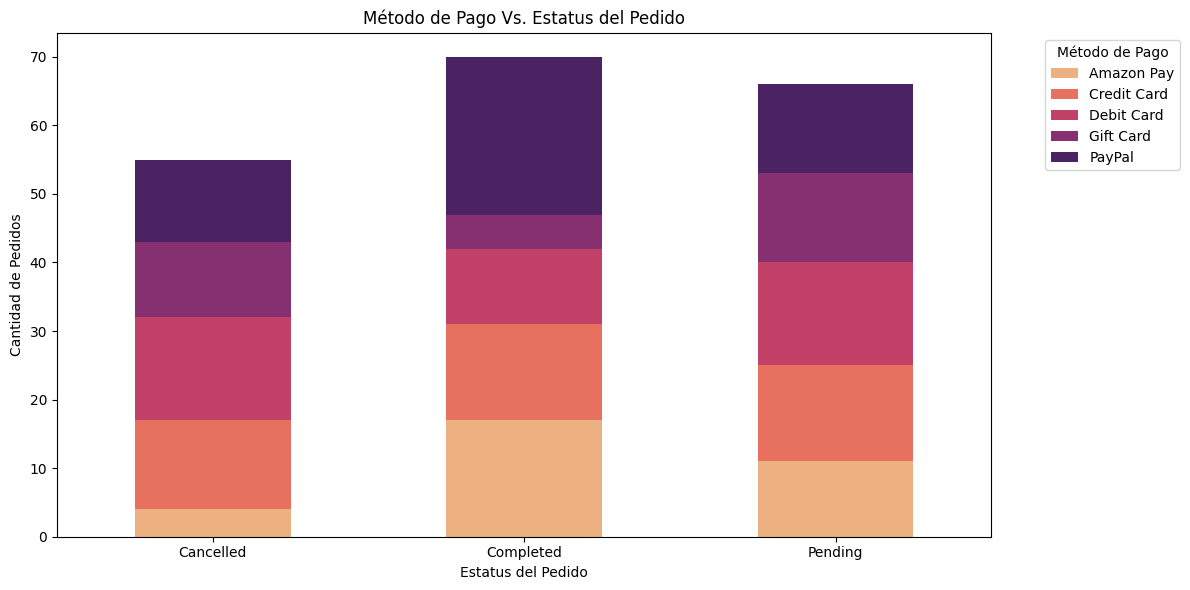

In [24]:
# Agrupar por estado del pedido y contar el tipo de pago
status_vs_payment = df.groupby('Status')['Payment Method'].value_counts().reset_index()

# Crear una tabla pivot 
pivot_df = status_vs_payment.pivot(index="Status", columns="Payment Method", values="count")

# Gráfico de barras apiladas
pivot_df.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="flare")

plt.title("Método de Pago Vs. Estatus del Pedido")
plt.ylabel("Cantidad de Pedidos")
plt.xlabel("Estatus del Pedido")
plt.xticks(rotation=0)
plt.legend(title="Método de Pago", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### ¿Hay alguna relación entre método de pago y estado del pedido?

En los pedidos completados, predominan los pagos con PayPal y Amazon Pay.
En los pedidos pendientes, las tarjetas de débito y crédito presentan incidencias similares y son las más utilizadas.
Por último, en los pedidos cancelados, se observa una mayor frecuencia de pagos con tarjeta de débito, seguidos por tarjeta de crédito.

Sin embargo, para determinar si hay una relación directa entre el estado del pedido y el método de pago, voy a realizar una prueba de hipótesis.

#### Prueba de hipótesis

- Hipótesis nula (H0): No hay relación entre el estado del pedido y el método de pago (son independientes).
- Hipótesis alternativa (H1): Sí hay relación (no son independientes).

Si el valor p es menor que el nivel de significancia (0.05), se rechaza la hipótesis nula y se concluye que hay relación.

In [25]:
# Importar libreria
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
tabla_contingencia = pd.crosstab(df['Status'], df['Payment Method'])

# Aplicar prueba Chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

# Mostrar resultados
print(f'Estadístico Chi-cuadrado: {chi2:.4f}')
print(f'Valor p: {p:.4f}')

# Interpretación
alpha = 0.05
if p < alpha:
    print("Se rechaza la hipótesis nula: existe relación significativa entre estado del pedido y método de pago.")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia de relación entre estado del pedido y método de pago.")


Estadístico Chi-cuadrado: 14.8908
Valor p: 0.0613
No se rechaza la hipótesis nula: no hay evidencia de relación entre estado del pedido y método de pago.


Con el valor p obtenido, no se rechaza la hipótesis nula, por lo que se concluye que no hay evidencia suficiente para afirmar que exista relación entre el estado del pedido y el método de pago.

### 3.3.3. Total de ventas por método de pago

/var/folders/82/grjgs_q959j1pwfb817_nsl80000gn/T/ipykernel_5321/3340188315.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Payment Method', y='Total Sales', data=total_sales_payment, palette=palette, ax=ax)


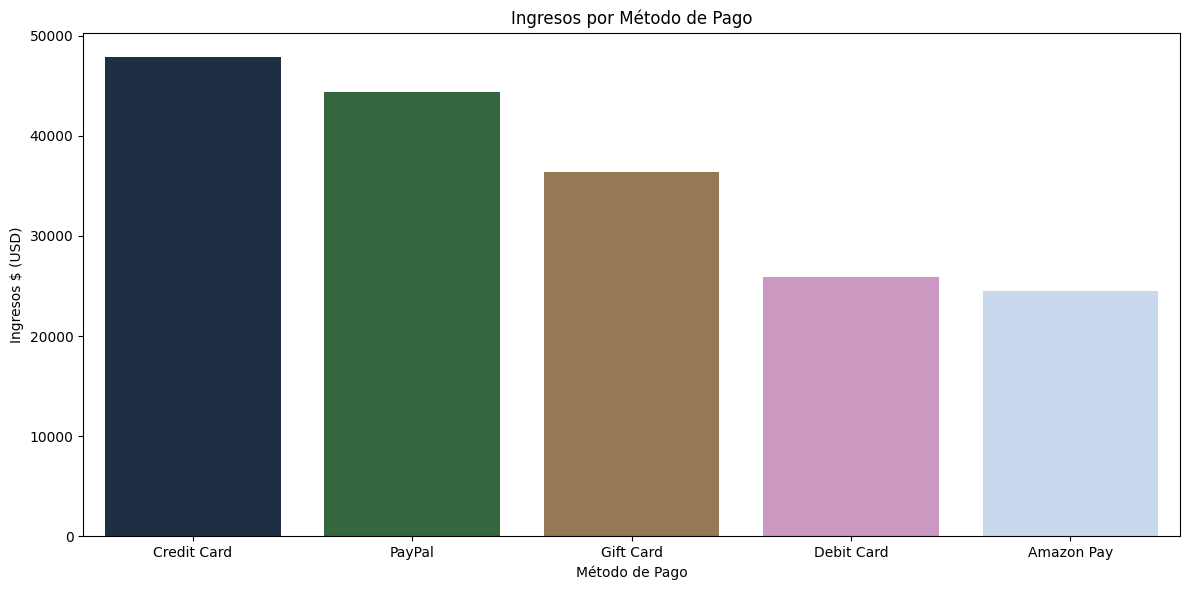

In [39]:
# Sumar los ingresos por metodo de pago
total_sales_payment = df.groupby('Payment Method')['Total Sales'].sum().reset_index()
total_sales_payment = total_sales_payment.sort_values(by='Total Sales', ascending=False)

# Crear el grafico
palette = sns.color_palette("cubehelix", n_colors=len(category_profit))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='Payment Method', y='Total Sales', data=total_sales_payment, palette=palette, ax=ax)
ax.set_title('Ingresos por Método de Pago')
ax.set_xlabel('Método de Pago')
ax.set_ylabel('Ingresos $ (USD)')
plt.tight_layout()
plt.show()

#### Ingresos por método de pago
PayPal concentra la mayoría de las transacciones, pero las tarjetas de crédito son el principal generador de ingresos.

--------
## 🔍 Hallazgos Significativos 

#### 1. Baja tasa de finalización de pedidos

Solo el 37% de los pedidos se completan exitosamente, mientras que el 34% permanece en estado pendiente y el 29% es cancelado.
Esto implica que casi dos de cada tres pedidos no se concretan, lo que representa una pérdida significativa de ingresos potenciales.

Recomendación:
- Investigar las causas detrás de los estados pendientes y cancelados (problemas logísticos, errores de pago, tiempos de entrega, etc.) y optimizar el embudo de conversión para aumentar la tasa de finalización.

#### 2. Ticket promedio de compra en $300 USD

El ticket promedio por órden de compra es de $300 USD.

Este valor es clave para definir promociones, segmentar campañas y establecer umbrales mínimos para beneficios como envíos gratuitos o descuentos.

#### 3. Disparidad entre volumen de ventas e ingresos generados

El reloj inteligente lidera en cantidad de unidades vendidas, seguido por jeans y laptops.
Sin embargo, el refrigerador, que se ubica en el 8.º lugar en volumen, es el producto que genera más ingresos, seguido por laptops y smartphones.
Esto indica que los productos de mayor valor unitario, aunque se vendan menos, tienen un mayor impacto en la rentabilidad.

Recomendación:
- Priorizar la visibilidad y promoción de productos de alto valor, ya que tienen un efecto desproporcionadamente positivo en los ingresos totales.

#### 4. Domingo: el día de mayor actividad

El domingo es el día con más órdenes de compra registradas.

Este patrón permite optimizar recursos operativos y logísticos (atención al cliente, campañas, stock) para ese día. También puede aprovecharse para lanzar promociones exclusivas durante el fin de semana.

#### 5. Tendencia a la baja en ventas desde abril

Las ventas alcanzaron su punto máximo entre febrero y marzo, pero comenzaron a disminuir en abril y continuaron cayendo en mayo.

Recomendación:
- Analizar posibles causas (estacionalidad, reducción de campañas, problemas de producto o servicio) e implementar acciones correctivas para evitar una caída prolongada.

#### 6. PayPal lidera en uso, pero las tarjetas de crédito lideran en ingresos

PayPal es el método más usado (25%), seguido por tarjetas de débito y crédito (21% cada una).
No obstante, las tarjetas de crédito generan mayores ingresos.
Los usuarios que realizan compras de mayor valor parecen preferir pagar con tarjeta de crédito, lo que puede estar relacionado con financiamiento o acumulación de beneficios.

Recomendación:
- Evaluar incentivos específicos según el método de pago (por ejemplo, descuentos con tarjetas en compras superiores a cierto monto) para aumentar el valor promedio de compra.

#### 7. No hay evidencia de relación entre estado del pedido y método de pago

Aunque ciertos métodos parecen más frecuentes en pedidos pendientes o cancelados, una prueba de hipótesis no mostró una relación estadísticamente significativa entre el estado del pedido y el método de pago.

Conclusión:
- Los métodos de pago no influyen directamente en el éxito o cancelación del pedido, lo que sugiere que las causas pueden estar en otras variables del proceso de compra.

## ✅ Conclusión general

El análisis revela una operación con potencial significativo de optimización, especialmente en términos de conversión de pedidos, promoción de productos de alto valor, y segmentación por método de pago y día de la semana.
Implementar acciones en estos puntos puede incrementar los ingresos, mejorar la experiencia del cliente y aumentar la eficiencia operativa.

---- 
## Preparación de Datos
Para este análisis utilicé Pandas, NumPy, Matplotlib y Seaborn. A continuación, detallo el proceso que seguí para preparar los datos antes del análisis exploratorio:

1. Verificación de datos duplicados y ausente

- Revisé el conjunto de datos en busca de duplicados y valores nulos. No se encontraron registros repetidos ni datos faltantes, por lo que no fue necesario aplicar procesos de limpieza en este aspecto.

2. Verificación de tipos de datos por columna

- La columna correspondiente a la fecha presentaba un tipo de dato inconsistente. Para facilitar el análisis temporal, convertí esta columna al formato datetime, lo que permitió trabajar correctamente con funciones de fechas y extraer periodos relevantes.

3. Revisión del periodo abarcado por el dataset

- Al explorar los valores extremos de la columna de fechas, observé que el dataset cubre el periodo del 3 de enero de 2025 al 3 de diciembre de 2025, es decir, un rango de 11 meses exactos.
Dado que se trata de datos simulados, este rango no necesariamente representa un comportamiento realista del presente año. Por esta razón, decidí filtrar el dataset hasta la fecha actual, utilizando pd.Timestamp.today() para limitar el análisis a un periodo más coherente.

4. Detección de outliers

- Tras analizar las estadísticas descriptivas, identifiqué posibles valores atípicos en la columna Ventas Totales. Al investigar más a fondo, comprobé que los valores más altos correspondían a productos de alto valor como refrigeradores y laptops.
Aunque estos casos son poco frecuentes, representan transacciones válidas dentro del contexto del negocio, por lo tanto no fueron considerados outliers reales. Sin embargo, es importante destacar que sí afectan la distribución, elevando el promedio general de ventas. Decidí conservarlos, ya que aportan información valiosa al análisis.

✅ Tras completar estos pasos, los datos quedaron listos para iniciar el análisis exploratorio.